# BioJEPA v0.7 Training Pipeline

In [1]:
import torch
import random
import gc
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

from biojepa_v0_7 import BioJepa, BioJepaConfig
from dataloader_v0_7 import EncoderLoader, ComposerLoader, TrainingLoader
from training_v0_7 import create_model, load_feature_banks, run_encoder_training, run_composer_training, run_ac_training, train_linear_decoder, maybe_compile
from config_v0_7 import EncoderTrainingConfig, ComposerTrainingConfig, ACTrainingConfig, DecoderConfig, DataConfig
from evals.evals import EvalContext, run_encoder_evals, run_composer_evals, run_ac_evals, save_report

## Device & Paths

In [2]:
SEED = 1337

def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        device = 'cuda'
    print(f'using {device}')
    return torch.device(device)

torch.manual_seed(SEED)
random.seed(SEED)
torch.set_float32_matmul_precision('high')

device = get_device()

USE_AMP = torch.cuda.is_available()
USE_COMPILE = torch.cuda.is_available()
USE_FUSED = torch.cuda.is_available()

data_root = Path('~/data/jepa/v0_7').expanduser()
ref_root = Path('~/data/jepa/reference_data').expanduser()

data_cfg = DataConfig(
    data_root=data_root,
    checkpoint_dir=data_root / 'checkpoint',
    ref_dir = ref_root,
    eval_results_dir=data_root / 'eval_results'
)

using cpu


## Hyperparameters

In [3]:
# Model architecture
model_cfg = BioJepaConfig(
    num_genes=10000,
    n_layer=2, #6
    heads=2, #4
    embed_dim= 8, #256
    mlp_ratio=4.0,
    n_pre_layer=2,
    mask_ratio=0.766,
    gaussian_scale=2.38,
    film_linear_multiple=0.81,
    sim_coeff=25,
    std_coeff=25,
    cov_coeff=1,
    pert_latent_dim=128,
    pert_mode_dim=64,
)

# Encoder training: WSD schedule with context L2 and EMA annealing in phase 2
encoder_cfg = EncoderTrainingConfig(
    n_steps = 1000,
    #epochs=1, 
    lr=1e-4, batch_size=64, phase2_start_pct=0.8, context_coeff=2.0, context_ramp_pct=0.2, ema_final_momentum=1.0,
)

# Composer training: InfoNCE loss with modality-balanced sampling (v0.7 HPO v3 winner)
composer_cfg = ComposerTrainingConfig(
    epochs=10000, lr=2.5e-4, batch_size=64, weight_decay=0.011, temperature=0.0015, chemical_fraction=0.1,
)

# AC training: conditioning dropout + mask annealing in final 20%
ac_cfg = ACTrainingConfig(
    n_steps = 1000,
    #epochs=1, 
    predictor_lr=1e-4, batch_size=32, mask_anneal_pct=0.2, mask_anneal_floor=0.0, p_uncond=0.1,
)

decoder_cfg = DecoderConfig(epochs=1, lr=1e-3, batch_size=32)

## Initialize Model & Data

In [4]:
model = create_model(model_cfg, device)
model = maybe_compile(model, USE_COMPILE)
seq_banks, target_bank = load_feature_banks(data_cfg, device)

print(f'Student/Teacher: {sum(p.numel() for p in model.student.parameters() if p.requires_grad):,}')
print(f'ACpredictor: {sum(p.numel() for p in model.predictor.parameters() if p.requires_grad):,}')
print(f'PerturbationComposer: {sum(p.numel() for p in model.composer.parameters() if p.requires_grad):,}')

Loaded DNA embeddings: torch.Size([11643, 1536])
Loaded chemical embeddings: torch.Size([188, 1536])
Loaded target embeddings: torch.Size([9975, 320])
Student/Teacher: 84,082
ACpredictor: 85,824
PerturbationComposer: 510,400


### Load pretraining model from checkpoint (for resuming)

In [5]:
checkpoint_path = data_cfg.checkpoint_dir / 'biojepa_v0_7_encoder_final.pt'
with torch.serialization.safe_globals([BioJepaConfig]):
    checkpoint = torch.load(checkpoint_path, map_location=device)

keys = model.load_state_dict(checkpoint['model'])
keys

<All keys matched successfully>

## Function to decompress and recompress a directory

In [ ]:
def decompress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'decompress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez(tmp_path, **arrays)
        tmp_path.replace(src_path)

def compress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'compress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez_compressed(tmp_path, **arrays)
        tmp_path.replace(src_path)

## Encoder Training

In [ ]:
# decompress_npz(data_cfg.data_root / 'encoder_t')

In [6]:
enc_train_loader = EncoderLoader(
    batch_size=encoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'encoder_t', 
    device=device )
enc_val_loader = EncoderLoader(
    batch_size=encoder_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'encoder_t', 
    device=device)

found 1175 shards for split train
shard balancing (threshold=133, 20% of max=664):
  adamson: 23 -> 138 shards (x6)
  k562e_raw: 98 -> 196 shards (x2)
  k562gw: 664 shards
  norman: 39 -> 156 shards (x4)
  rep1e: 83 -> 166 shards (x2)
  sciplex: 268 shards
found 70 shards for split val


In [6]:
pt_results = run_encoder_training(model, enc_train_loader, enc_val_loader, encoder_cfg, device, data_cfg, model_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED, eval_every_n_epochs=2)

Encoder training: 4065280 samples, 63520 steps/epoch, 1000 total steps
WSD schedule: warmup=50 steps, phase2 starts at step 800
Context L2: target=2.0, ramp starts at step 800
EMA annealing: 0.995 -> 1.0 during phase 2
Step 0 | val loss: 74.7014
Step 0 | Loss: 74.12534 | LR: 2.00e-06 | Phase: 1
Step 100 | Loss: 58.85537 | LR: 1.00e-04 | Phase: 1
Step 200 | Loss: 37.85822 | LR: 1.00e-04 | Phase: 1
Step 300 | Loss: 27.65254 | LR: 1.00e-04 | Phase: 1
Step 400 | Loss: 23.82232 | LR: 1.00e-04 | Phase: 1
Step 500 | val loss: 16.2770
Step 500 | Loss: 16.20064 | LR: 1.00e-04 | Phase: 1
Step 600 | Loss: 15.81695 | LR: 1.00e-04 | Phase: 1
Step 700 | Loss: 19.41695 | LR: 1.00e-04 | Phase: 1
Step 800 | Loss: 19.30061 | LR: 9.95e-05 | Phase: 2
Step 900 | Loss: 21.62449 | LR: 4.95e-05 | Phase: 2
Step 999 | val loss: 20.9004


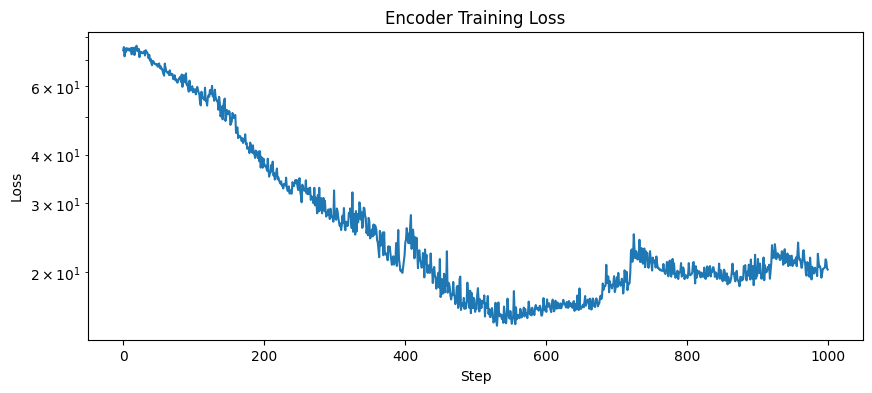

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(pt_results['loss_history'])
plt.yscale('log')
plt.title('Encoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [8]:
if pt_results['epoch_evals']:
    evals_df = pd.DataFrame({e: d['metrics'] for e, d in pt_results['epoch_evals'].items()}).T
    evals_df.index = evals_df.index.astype(int)
    evals_df.index.name = 'epoch'
    evals_df.sort_index()

### Encoder Training Evals

In [9]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': encoder_cfg.batch_size, 'seed': SEED
}
model.eval()
eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
eval_ctx._biojepa = model
pt_eval_results = run_encoder_evals(eval_ctx)
eval_ctx._biojepa = None

save_report(pt_eval_results, data_cfg.eval_results_dir / 'encoder_eval_report.json')
pt_eval_results

Using cpu
found 135 shards for split test


batch_invariance: Extracting embeddings:  92%|█████████████▊ | 4982/5400 [1:06:28<05:34,  1.25it/s]


KeyboardInterrupt: 

In [ ]:
# compress_npz(data_cfg.data_root / 'encoder_t')

In [ ]:
del enc_train_loader, enc_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()
model.train()

## Stage 2: Composer Training

In [ ]:
comp_train_loader = ComposerLoader(
    batch_size=composer_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device, total_samples=1250,
    seed=1337, chemical_fraction=composer_cfg.chemical_fraction)
comp_val_loader = ComposerLoader(
    batch_size=composer_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device)

In [ ]:
align_results = run_composer_training(model, comp_train_loader, comp_val_loader, seq_banks, target_bank, composer_cfg, device, data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(align_results['loss_history'])
plt.yscale('log')
plt.title('Composer Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### Composer Training Evals

In [ ]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': composer_cfg.batch_size, 'seed': SEED
}
model.eval()
align_eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
align_eval_ctx._biojepa = model
align_eval_results = run_composer_evals(align_eval_ctx)
align_eval_ctx._biojepa = None

save_report(align_eval_results, data_cfg.eval_results_dir / 'composer_eval_report.json')
align_eval_results

In [ ]:
del comp_train_loader, comp_val_loader, align_eval_ctx
gc.collect()
torch.cuda.empty_cache()
model.train()

## Stage 3: AC Training

In [ ]:
train_loader = TrainingLoader(
    batch_size=ac_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)
val_loader = TrainingLoader(
    batch_size=ac_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)

full_results = run_ac_training(model, train_loader, val_loader, seq_banks, target_bank, ac_cfg, device, data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(full_results['loss_history'])
plt.title('AC Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [ ]:
del train_loader, val_loader
gc.collect()
torch.cuda.empty_cache()

## Linear Decoder Training

In [ ]:
decoder_train_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device, 
    total_samples=101682)
decoder_val_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size,
    split='val', data_dir=data_cfg.data_root / 'predictor_t',
    device=device,
    total_samples=11044)

decoder, decoder_results = train_linear_decoder(model, decoder_train_loader, decoder_val_loader, seq_banks, target_bank, model_cfg, device, data_cfg.checkpoint_dir, decoder_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(decoder_results['loss_history'])
plt.title('Decoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

## AC Evals

In [ ]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': ac_cfg.batch_size, 'seed': SEED
}
model.eval()
eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
eval_ctx._biojepa = model
eval_ctx._decoder = decoder
full_eval_results = run_ac_evals(eval_ctx)
eval_ctx._biojepa = None

save_report(full_eval_results, data_cfg.eval_results_dir / 'ac_eval_report.json')
full_eval_results

In [ ]:
del decoder_train_loader, decoder_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Summary

In [ ]:
print('=== Training Complete ===')
print(f'Encoder training final loss: {pt_results["final_loss"]:.5f}')
print(f'Composer training final loss: {align_results["final_loss"]:.5f}')
print(f'AC training final loss: {full_results["final_loss"]:.5f}')
print(f'Decoder final loss: {decoder_results["final_loss"]:.5f}')
print(f'\nCheckpoints saved to: {data_cfg.checkpoint_dir}')
print(f'Eval reports saved to: {data_cfg.eval_results_dir}')